<a href="https://colab.research.google.com/github/fedhere/DSPS_FBianco/blob/master/labs/NearestNeighborsIris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import sklearn

In [1]:
from sklearn import datasets

In [2]:
#loading the iris dataset: a historical dataset of features of plants for classification, the target variable is the iris spicies
iris = datasets.load_iris()

In [3]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [4]:
iris.data.shape

(150, 4)

In [6]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

 seaborn is a python visualizaton package that offers some computational modeling in service of its visualizations

 I will use it to make a scatter matrix (that typically looks a lot better than the default pandas one) and also slightly enhance that visualization by producing a pairplot which on the diagonal has a Kernel Density Estimate - which is essentially a smooth histogram


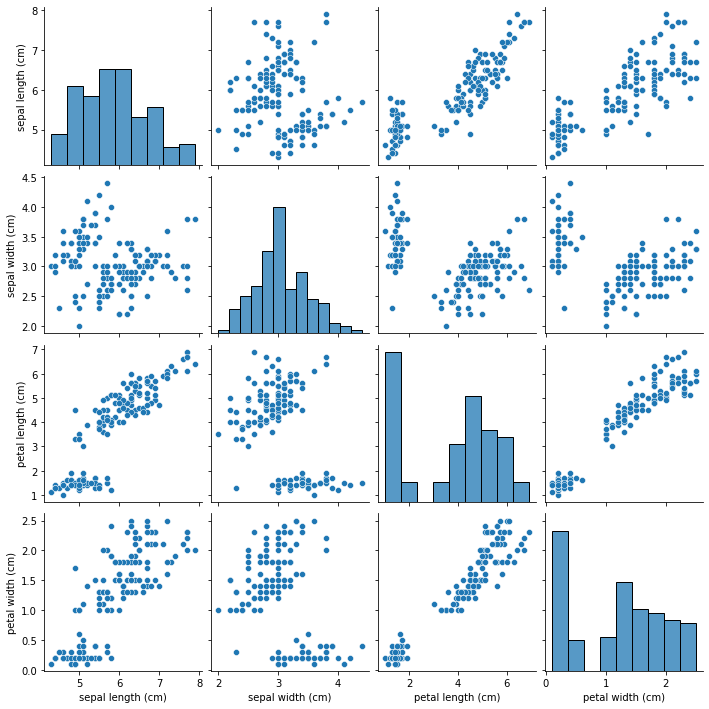

In [7]:
import seaborn as sns
import pandas as pd
sns.pairplot(pd.DataFrame(data=iris.data,
                          columns=iris.feature_names))


In [8]:
# note that the target variable is sorted so whatever model I make up I have to shuffle the data!
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

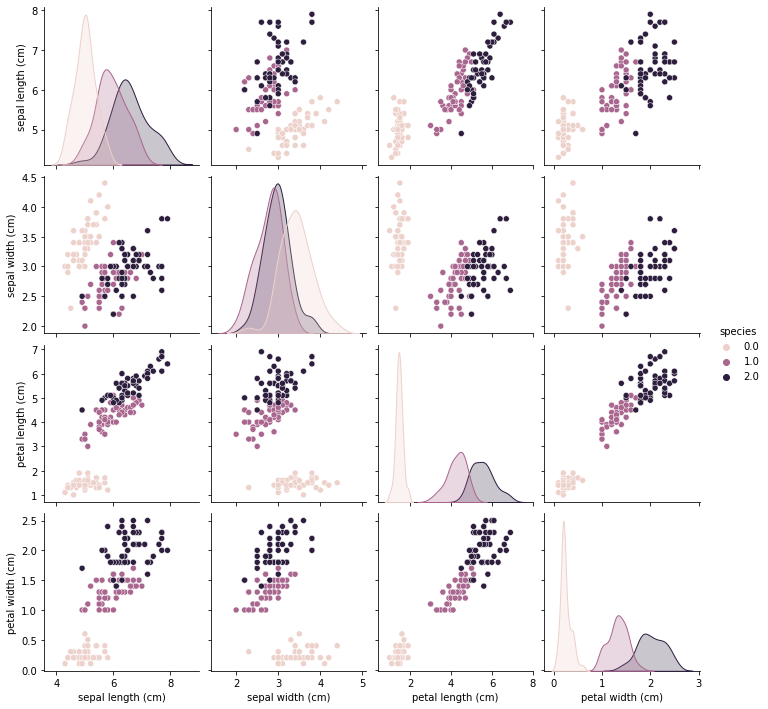

In [10]:
#putting the target together with the data to colorcode the scatter matrix
import numpy as np
sns.pairplot(pd.DataFrame(data=np.vstack([iris.data.T, iris.target]).T,
                          columns=iris.feature_names + ["species"]), hue="species")

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
trainX, trainy, testX, testy = train_test_split(iris.data, iris.target, test_size=0.1)

Calculate the distance between all points in the feature space

In [13]:
import scipy
from scipy.spatial import distance
distance.squareform(distance.pdist(iris.data))

array([[0.        , 0.53851648, 0.50990195, ..., 4.45982062, 4.65080638,
        4.14004831],
       [0.53851648, 0.        , 0.3       , ..., 4.49888875, 4.71805044,
        4.15331193],
       [0.50990195, 0.3       , 0.        , ..., 4.66154481, 4.84871117,
        4.29883705],
       ...,
       [4.45982062, 4.49888875, 4.66154481, ..., 0.        , 0.6164414 ,
        0.64031242],
       [4.65080638, 4.71805044, 4.84871117, ..., 0.6164414 , 0.        ,
        0.76811457],
       [4.14004831, 4.15331193, 4.29883705, ..., 0.64031242, 0.76811457,
        0.        ]])

Because we did not shuffle we have a block structure in the distance matrix... this suggests that indeed the classes based on the target variables reflect a structure in the data


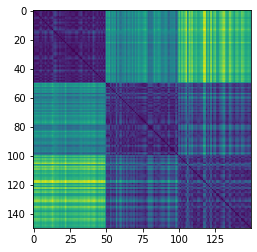

In [14]:
import pylab as pl
pl.imshow(distance.squareform(distance.pdist(iris.data)))

In [15]:
#putting together the features and target to shuffle the data
import numpy as np
np.vstack([iris.data.T, iris.target])

array([[5.1, 4.9, 4.7, 4.6, 5. , 5.4, 4.6, 5. , 4.4, 4.9, 5.4, 4.8, 4.8,
        4.3, 5.8, 5.7, 5.4, 5.1, 5.7, 5.1, 5.4, 5.1, 4.6, 5.1, 4.8, 5. ,
        5. , 5.2, 5.2, 4.7, 4.8, 5.4, 5.2, 5.5, 4.9, 5. , 5.5, 4.9, 4.4,
        5.1, 5. , 4.5, 4.4, 5. , 5.1, 4.8, 5.1, 4.6, 5.3, 5. , 7. , 6.4,
        6.9, 5.5, 6.5, 5.7, 6.3, 4.9, 6.6, 5.2, 5. , 5.9, 6. , 6.1, 5.6,
        6.7, 5.6, 5.8, 6.2, 5.6, 5.9, 6.1, 6.3, 6.1, 6.4, 6.6, 6.8, 6.7,
        6. , 5.7, 5.5, 5.5, 5.8, 6. , 5.4, 6. , 6.7, 6.3, 5.6, 5.5, 5.5,
        6.1, 5.8, 5. , 5.6, 5.7, 5.7, 6.2, 5.1, 5.7, 6.3, 5.8, 7.1, 6.3,
        6.5, 7.6, 4.9, 7.3, 6.7, 7.2, 6.5, 6.4, 6.8, 5.7, 5.8, 6.4, 6.5,
        7.7, 7.7, 6. , 6.9, 5.6, 7.7, 6.3, 6.7, 7.2, 6.2, 6.1, 6.4, 7.2,
        7.4, 7.9, 6.4, 6.3, 6.1, 7.7, 6.3, 6.4, 6. , 6.9, 6.7, 6.9, 5.8,
        6.8, 6.7, 6.7, 6.3, 6.5, 6.2, 5.9],
       [3.5, 3. , 3.2, 3.1, 3.6, 3.9, 3.4, 3.4, 2.9, 3.1, 3.7, 3.4, 3. ,
        3. , 4. , 4.4, 3.9, 3.5, 3.8, 3.8, 3.4, 3.7, 3.6, 3.3, 3.4, 3. ,
       

In [89]:
from random import shuffle
np.random.seed(451)
ind_list = list(range(len(iris.target)))
shuffle(ind_list)
data = iris.data[ind_list]
data = data.reshape(150,4)
target = iris.target[ind_list]
data[:3], iris.data[:3]

(array([[7.3, 2.9, 6.3, 1.8],
        [7.2, 3.2, 6. , 1.8],
        [5.7, 4.4, 1.5, 0.4]]), array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2]]))

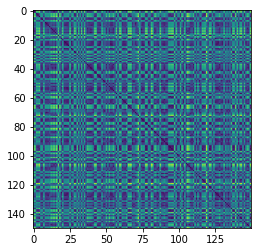

In [91]:
#no block structure in the matrix after shuffling
pl.imshow(distance.squareform(distance.pdist(data)))

In [17]:
#distances to the 0-th datapoint
dist = distance.squareform(distance.pdist(iris.data))[0]

In [18]:
np.argsort(dist)

array([  0,  17,   4,  39,  28,  27,  40,   7,  49,  37,  21,  48,  26,
        19,  46,  35,  11,  10,  31,  36,  20,  34,  43,   9,  23,   2,
         6,  29,   1,  30,  25,  16,  47,  12,  24,  45,  44,   5,  32,
        22,   3,  18,  42,  33,  38,  14,   8,  13,  15,  41,  98,  57,
        93,  79,  64,  81,  60,  80,  69,  59,  82,  88,  67,  92,  89,
        99,  95,  71,  53,  96,  62,  94,  61,  90,  97,  84,  74,  55,
        66,  85,  78, 106,  91,  75,  51,  87,  65,  73,  63,  58,  68,
        56,  54,  70, 138,  86, 126,  50, 127, 121,  76,  72, 123,  83,
       149, 119, 133,  52, 113, 101, 142,  77, 146, 110, 114, 147, 111,
       134, 137, 115, 141, 116, 148, 145, 103, 139, 128, 112, 132, 136,
       124, 140, 108, 104, 129, 120, 144, 143, 100, 102, 125, 130, 107,
       109, 135, 131, 105, 122, 117, 118])

In [19]:
dist[np.argsort(dist)]

array([0.        , 0.1       , 0.14142136, 0.14142136, 0.14142136,
       0.14142136, 0.17320508, 0.17320508, 0.2236068 , 0.24494897,
       0.3       , 0.3       , 0.31622777, 0.33166248, 0.36055513,
       0.37416574, 0.37416574, 0.37416574, 0.38729833, 0.41231056,
       0.43588989, 0.45825757, 0.45825757, 0.46904158, 0.46904158,
       0.50990195, 0.51961524, 0.53851648, 0.53851648, 0.53851648,
       0.54772256, 0.54772256, 0.58309519, 0.59160798, 0.59160798,
       0.59160798, 0.6164414 , 0.6164414 , 0.6244998 , 0.64807407,
       0.64807407, 0.74161985, 0.76811457, 0.80622577, 0.8660254 ,
       0.88317609, 0.92195445, 0.99498744, 1.1045361 , 1.34907376,
       2.0904545 , 2.34520788, 2.38746728, 2.49399278, 2.58069758,
       2.70185122, 2.70370117, 2.81780056, 2.88270706, 2.88790582,
       2.89482297, 3.        , 3.00998339, 3.00998339, 3.02158899,
       3.05777697, 3.07408523, 3.0757113 , 3.09354166, 3.12569992,
       3.14642654, 3.15277655, 3.22800248, 3.31209903, 3.34514

In [32]:
K = 10
# target variable value of 10 observations closest to observcation 0
iris.target[np.argsort(dist)][1:1+K]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [37]:
# predicting the target of observation 0 with 10 nearest-neighbors
# (trivial in this case because all neightbors are 0 
# but done for the general case when the target variable may be mixed)
print("target variable prediction based on " 
      "K={} neighbors: {}".format(K, 
              np.unique(iris.target[np.argsort(dist)][1:1+K], 
                        return_counts=True)[0][0]))

target variable prediction based on K=10 neighbors: 0
